In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [104]:
df=pd.read_csv('StudentPerformanceFactors.csv')

 Exploration and cleaning

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [37]:
print ('data size is', df.shape)
df.head()

data size is (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [38]:
#finding missing values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [39]:
df['Teacher_Quality'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
6602    False
6603    False
6604    False
6605    False
6606    False
Name: Teacher_Quality, Length: 6607, dtype: bool

In [105]:
#removing rows with missing values:
dfclean=df.dropna()
print ('the cleaned data size is',dfclean.shape)
print ('the number of deleted rows is', df.shape[0]-dfclean.shape[0])
dfclean.isnull().sum()

the cleaned data size is (6378, 20)
the number of deleted rows is 229


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

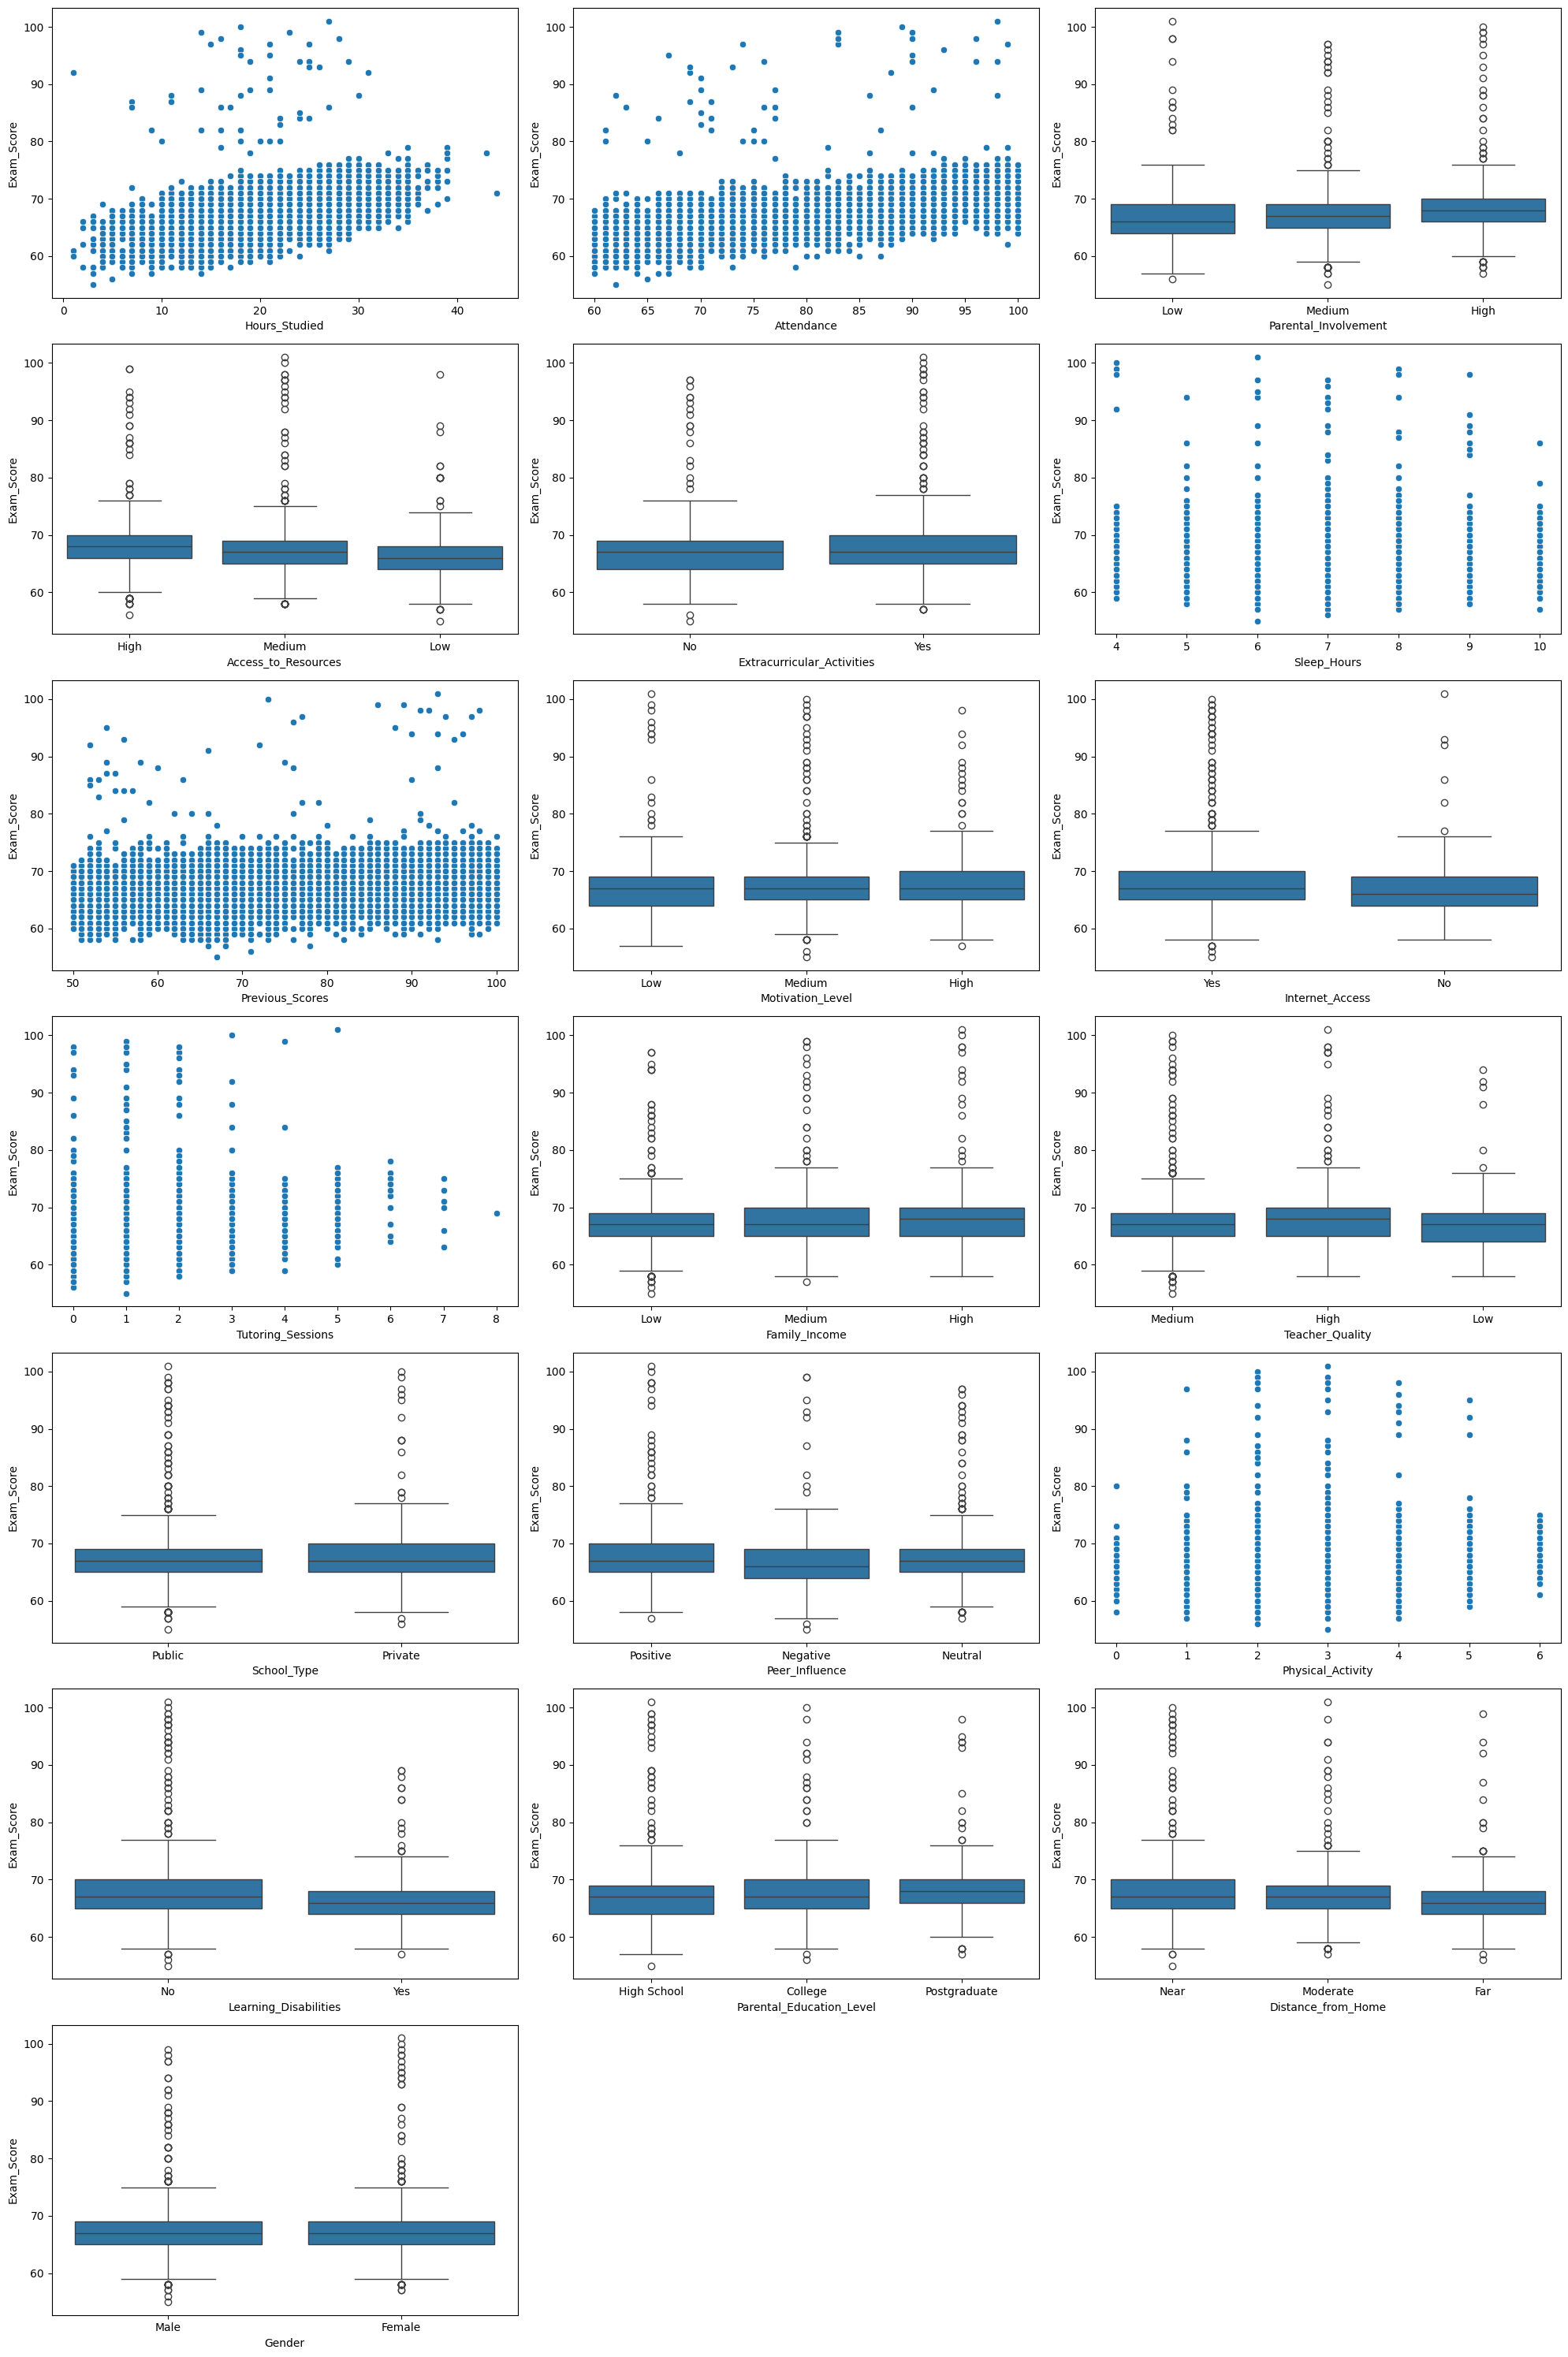

In [83]:
plt.figure(figsize=(20,30))

for i, col in enumerate(df.columns[:-1],1):
    plt.subplot(7,3,i)
    if df[col].dtype == 'int64':
        sns.scatterplot(data=dfclean, x=col, y='Exam_Score')
        #axes[i].title('Excam_Score vs.', var)
    else:
        sns.boxplot(data=df, x=col, y='Exam_Score')
        #axes[i].title('Excam_Score vs.', var)
plt.tight_layout()        
plt.show()        
    


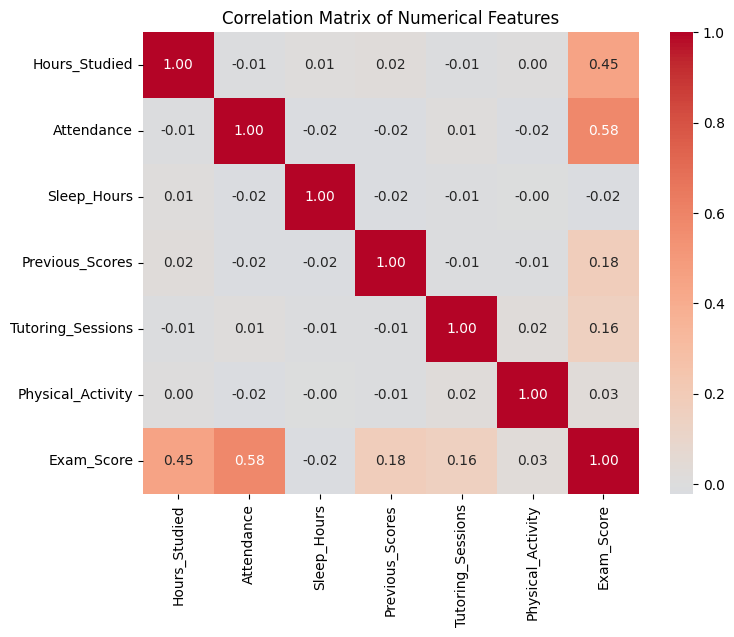

In [77]:
numerical_cols = df.select_dtypes(include=['number'])
corr_matrix = numerical_cols.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [108]:
categorical_cols = df.select_dtypes(include='object').columns
df1 = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
corr_matrix = df1.corr()
target_corr = corr_matrix['Exam_Score'].sort_values(ascending=False)
#plt.figure(figsize=(20, 18))
#sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,fmt=".2f")
print(target_corr)

Exam_Score                               1.000000
Attendance                               0.581072
Hours_Studied                            0.445455
Previous_Scores                          0.175079
Tutoring_Sessions                        0.156525
Parental_Education_Level_Postgraduate    0.093764
Distance_from_Home_Near                  0.084870
Peer_Influence_Positive                  0.081217
Extracurricular_Activities_Yes           0.064382
Internet_Access_Yes                      0.051475
Physical_Activity                        0.027824
Motivation_Level_Medium                  0.024771
Family_Income_Medium                     0.020995
Gender_Male                             -0.002032
Peer_Influence_Neutral                  -0.007795
School_Type_Public                      -0.008844
Sleep_Hours                             -0.017022
Access_to_Resources_Medium              -0.026158
Parental_Involvement_Medium             -0.035978
Teacher_Quality_Medium                  -0.039294


In [90]:
from sklearn.model_selection import train_test_split

In [164]:
#lets select feasures with correlation more than 0.05
selected_features = target_corr[abs(target_corr) > 0.05].index.tolist()
selected_features.remove('Exam_Score')
X = df1[selected_features]
y = df1['Exam_Score']
print(X.shape)
print(y.shape)


(6607, 15)
(6607,)


In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [139]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("RMSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))

RMSE: 5.835461022247793
R^2: 0.5871644073016724


In [140]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [157]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}



In [165]:
def categorize(score):
    if score<40:
        return "Low"
    elif score<70:
        return "Medium"
    else:
        return "High"
y=df1['Exam_Score']
#X = dfclean[selected_features]
y = y.apply(categorize)

X = df1[selected_features]

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [167]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  # accuracy in %
    results[name] = acc
    print(f"{name}: {acc:.2f}%")

Logistic Regression: 91.30%
Decision Tree: 84.64%
Random Forest: 89.41%
Gradient Boosting: 90.54%
AdaBoost: 90.17%
SVM: 89.64%
Naive Bayes: 89.41%
KNN: 87.52%


C:\Users\124628\AppData\Local\Temp\ipykernel_21172\4244238550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


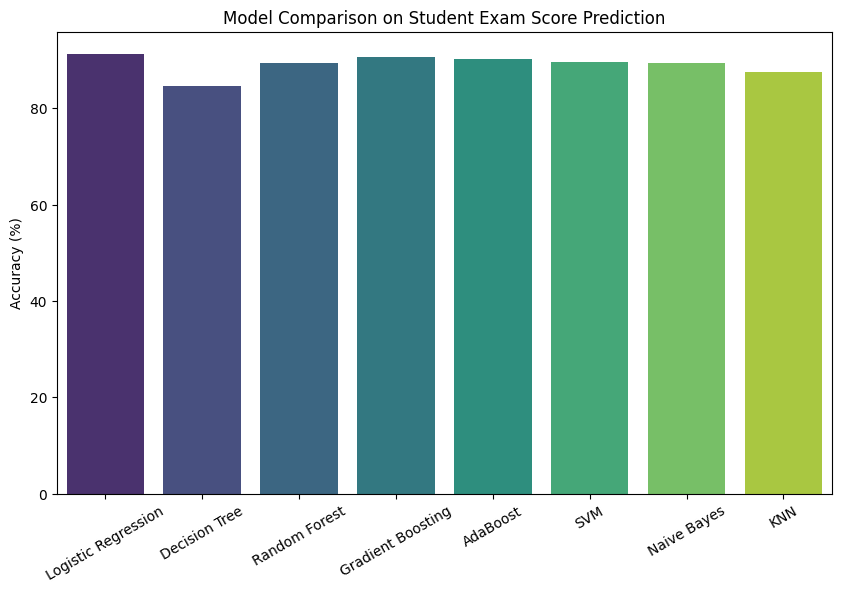

In [168]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.xticks(rotation=30)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison on Student Exam Score Prediction")
plt.show()